In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_columns',None)

In [75]:
df = pd.read_csv("social_media_actionable_dataset.csv")

In [76]:
df.head()

,post_id,platform,user_id,text,timestamp,brand,brand_mentioned,actionable,issue_type
0,P00001,Twitter,U4657,I love this product!,2025-07-10 02:03:54.338559,BrandC,True,0,NaN
1,P00002,Reddit,U2535,The weather is nice today.,2025-10-28 02:03:54.338586,BrandA,True,0,NaN
2,P00003,Facebook,U8359,I love this product!,2025-07-23 02:03:54.338595,BrandD,False,0,NaN
3,P00004,Reddit,U3547,Just sharing my thoughts.,2025-06-23 02:03:54.338603,BrandC,True,0,NaN
4,P00005,Twitter,U6881,Amazing experience overall.,2025-09-24 02:03:54.338614,BrandD,False,0,NaN


In [77]:
df.shape

(50000, 9)

In [78]:
df.columns

Index(['post_id', 'platform', 'user_id', 'text', 'timestamp', 'brand',
       'brand_mentioned', 'actionable', 'issue_type'],
      dtype='str')

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   post_id          50000 non-null  str  
 1   platform         50000 non-null  str  
 2   user_id          50000 non-null  str  
 3   text             50000 non-null  str  
 4   timestamp        50000 non-null  str  
 5   brand            50000 non-null  str  
 6   brand_mentioned  50000 non-null  bool 
 7   actionable       50000 non-null  int64
 8   issue_type       25033 non-null  str  
dtypes: bool(1), int64(1), str(7)
memory usage: 3.1 MB


In [80]:
df.describe(include='all')

,post_id,platform,user_id,text,timestamp,brand,brand_mentioned,actionable,issue_type
count,50000,50000,50000,50000,50000,50000,50000,50000.000000,25033
unique,50000,4,8961,10,50000,4,2,NaN,5
top,P00001,Facebook,U6865,My payment failed but money was deducted.,2025-07-10 02:03:54.338559,BrandB,False,NaN,Suggestion
freq,1,12524,17,5159,1,12632,25003,NaN,5117
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500660,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500005,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


In [81]:
df['actionable'].value_counts()

actionable
1    25033
0    24967
Name: count, dtype: int64

In [82]:
df['platform'].value_counts()

platform
Facebook     12524
Instagram    12520
Reddit       12482
Twitter      12474
Name: count, dtype: int64

In [83]:
df['issue_type'].value_counts()

issue_type
Suggestion    5117
Feedback      5042
Question      4996
Praise        4973
Complaint     4905
Name: count, dtype: int64

In [84]:
df['message_length'] = df['text'].str.len()

In [85]:
issue_plot = df['issue_type'].fillna('Non_Actionable')

In [86]:
issue_plot

0        Non_Actionable
1        Non_Actionable
2        Non_Actionable
3        Non_Actionable
4        Non_Actionable
              ...      
49995        Suggestion
49996         Complaint
49997    Non_Actionable
49998    Non_Actionable
49999            Praise
Name: issue_type, Length: 50000, dtype: str

In [87]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [88]:
def clean_text(text):

    # convert to string
    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtags symbol
    text = re.sub(r'#', '', text)

    # remove numbers (optional)
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenization
    tokens = text.split()

    # stopword removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [89]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [90]:
for i in range(5):

    print("ORIGINAL:")
    print(df['text'].iloc[i])

    print("\nCLEANED:")
    print(df['cleaned_text'].iloc[i])

    print("\n" + "="*100 + "\n")

ORIGINAL:
I love this product!

CLEANED:
love product


ORIGINAL:
The weather is nice today.

CLEANED:
weather nice today


ORIGINAL:
I love this product!

CLEANED:
love product


ORIGINAL:
Just sharing my thoughts.

CLEANED:
sharing thought


ORIGINAL:
Amazing experience overall.

CLEANED:
amazing experience overall




In [91]:
(df['cleaned_text'].str.len() == 0).sum()

np.int64(0)

In [92]:
df.to_csv(
    "social_media_actionable_cleaned.csv",
    index=False
)

In [93]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['actionable']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [95]:
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (40000, 30)
Testing Shape: (10000, 30)


In [96]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['amazing' 'app' 'arrived' 'assist' 'cool' 'crashing' 'deducted'
 'experience' 'failed' 'hasnt' 'help' 'issue' 'keep' 'login' 'love'
 'money' 'nice' 'order' 'overall' 'password' 'payment' 'please' 'product'
 'reset' 'sharing' 'someone' 'thought' 'today' 'weather' 'yet']


In [97]:
print("Vocabulary Size:", len(feature_names))

Vocabulary Size: 30


In [98]:
df.groupby('text')['actionable'].nunique().value_counts()

actionable
1    10
Name: count, dtype: int64

In [99]:
print("Unique texts:", df['text'].nunique())
print("Unique cleaned texts:", df['cleaned_text'].nunique())

Unique texts: 10
Unique cleaned texts: 10


In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [102]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4993
           1       1.00      1.00      1.00      5007

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



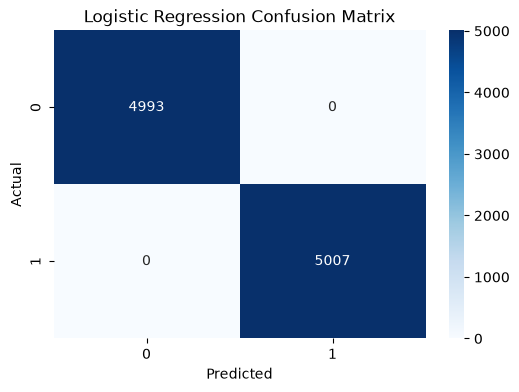

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

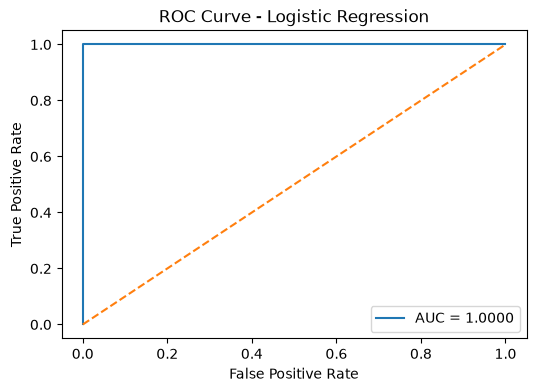

In [106]:
from sklearn.metrics import roc_curve, auc

y_prob = lr_model.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [107]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_lr)],
    "Recall": [recall_score(y_test, y_pred_lr)],
    "F1 Score": [f1_score(y_test, y_pred_lr)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0


# Random Forest Classifier

In [108]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [109]:
y_pred_rf = rf_model.predict(X_test_tfidf)

In [110]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [111]:
results.loc[len(results)] = [
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [112]:
feature_importance = pd.DataFrame({
    'Feature': tfidf.get_feature_names_out(),
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
19,password,0.086865
23,reset,0.084162
1,app,0.062655
5,crashing,0.054698
12,keep,0.052190
13,login,0.048397
4,cool,0.040825
25,someone,0.038614
11,issue,0.038425
24,sharing,0.036975


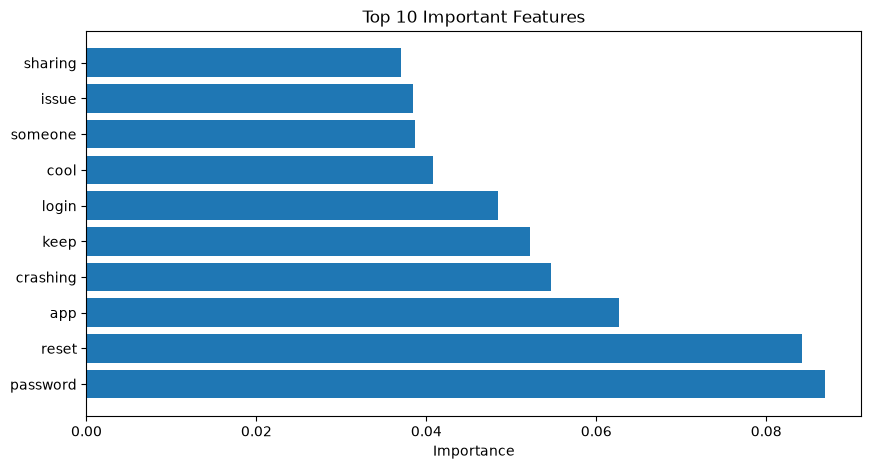

In [113]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.show()

# SVM

In [114]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [115]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [116]:
results.loc[len(results)] = [
    "SVM",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0


In [117]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [118]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb_model.predict(X_test_tfidf)

In [119]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [120]:
results.loc[len(results)] = [
    "XGBoost",
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb)
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0


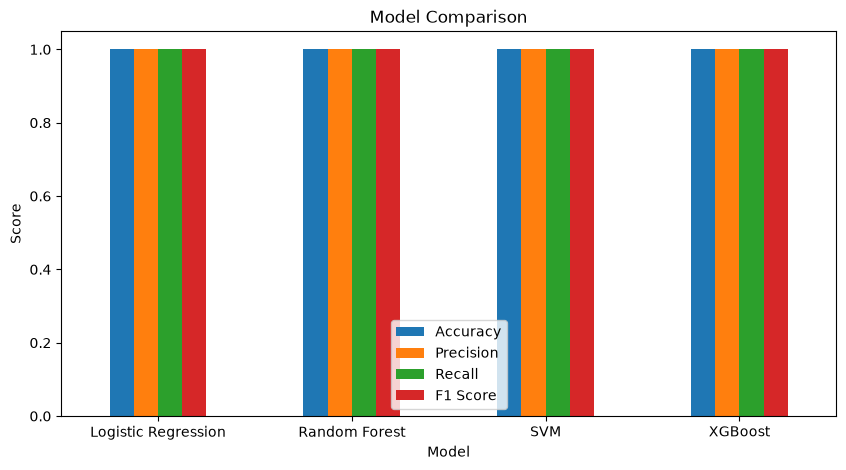

In [121]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

# Deep Learning
LSTM

In [122]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [123]:
X = df['cleaned_text']
y = df['actionable']

In [124]:
max_words = 5000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X)

In [125]:
sequences = tokenizer.texts_to_sequences(X)

In [126]:
lengths = [len(seq) for seq in sequences]

print("Max Length:", max(lengths))
print("Average Length:", sum(lengths)/len(lengths))

Max Length: 6
Average Length: 3.00916


In [127]:
max_len = 20

X_pad = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [128]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

In [130]:
vocab_size = len(tokenizer.word_index) + 1

model = Sequential([
    
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len
    ),
    
    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    
    Dense(
        32,
        activation='relu'
    ),
    
    Dropout(0.2),
    
    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\Abarna Studio\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [131]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [132]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 64)         │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,185 (145.25 KB)

 Trainable params: 37,185 (145.25 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9816 - loss: 0.0316 - val_accuracy: 1.0000 - val_loss: 2.4782e-06
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 1.0000 - loss: 1.6154e-05 - val_accuracy: 1.0000 - val_loss: 3.2529e-07
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 1.0000 - loss: 5.2290e-06 - val_accuracy: 1.0000 - val_loss: 8.5790e-08
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 1.0000 - loss: 2.5983e-06 - val_accuracy: 1.0000 - val_loss: 2.3912e-08
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 1.0000 - loss: 1.8767e-06 - val_accuracy: 1.0000 - val_loss: 7.3619e-09


In [134]:
loss, accuracy = model.evaluate(
    X_test_dl,
    y_test_dl
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 7.3547e-09
Test Accuracy: 1.0


In [135]:
y_prob = model.predict(X_test_dl)

y_pred_lstm = (
    y_prob > 0.5
).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [136]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test_dl, y_pred_lstm))
print("Precision:", precision_score(y_test_dl, y_pred_lstm))
print("Recall   :", recall_score(y_test_dl, y_pred_lstm))
print("F1 Score :", f1_score(y_test_dl, y_pred_lstm))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [137]:
results.loc[len(results)] = [
    "LSTM",
    accuracy_score(y_test_dl, y_pred_lstm),
    precision_score(y_test_dl, y_pred_lstm),
    recall_score(y_test_dl, y_pred_lstm),
    f1_score(y_test_dl, y_pred_lstm)
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0
4,LSTM,1.0,1.0,1.0,1.0


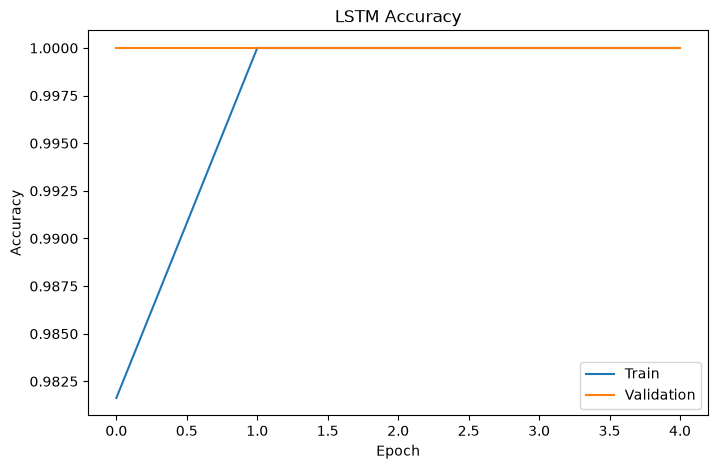

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

### Vocabulary Analysis

In [139]:
print("Total Rows:", len(df))
print("Unique Texts:", df['text'].nunique())
print("Unique Cleaned Texts:", df['cleaned_text'].nunique())
print("Vocabulary Size:", len(tokenizer.word_index))

Total Rows: 50000
Unique Texts: 10
Unique Cleaned Texts: 10
Vocabulary Size: 31


In [140]:
import joblib

joblib.dump(lr_model, "logistic_regression.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [141]:
model.save("lstm_model.keras")